In [1]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')


In [2]:
cluster_df = pd.read_csv("olist_cleaned_dataset.csv")


In [3]:
cluster_df.head()

,customer_unique_id,num_orders,total_spent,avg_order_value,avg_item_price_per_order,avg_items_per_order,avg_review,avg_installments,city,state,...,cat_pca_1,cat_pca_2,cat_pca_3,cat_pca_4,cat_pca_5,cat_pca_6,cat_pca_7,cat_pca_8,cat_pca_9,cat_pca_10
0,0000366f3b9a7992bf8c76cfdf3221e2,-0.159829,-0.015717,0.003713,0.021035,-0.172165,0.663285,1.898826,cajamar,SP,...,-0.637624,-0.327896,-0.102259,0.059743,-0.020116,0.189493,-0.198020,0.051733,0.008437,0.073418
1,0000b849f77a49e4a4ce2b2a4ca5be3f,-0.159829,-0.574829,-0.570550,-0.561497,-0.172165,-0.120408,-0.707834,osasco,SP,...,-0.209777,0.588827,0.471880,-0.118288,-0.149629,0.046770,-0.092128,0.047734,-0.035847,0.026227
2,0000f46a3911fa3c0805444483337064,-0.159829,-0.322473,-0.311356,-0.298570,-0.172165,-0.904101,1.898826,sao jose,SC,...,-0.018761,-0.047356,-0.095521,0.369686,0.141457,-0.068647,0.166585,0.079676,0.160974,-0.034467
3,0000f6ccb0745a6a4b88665a16c9f078,-0.159829,-0.539117,-0.533870,-0.524289,-0.172165,-0.120408,0.409306,belem,PA,...,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480
4,0004aac84e0df4da2b147fca70cf8255,-0.159829,0.236639,0.262908,0.283963,-0.172165,0.663285,1.154066,sorocaba,SP,...,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480


In [4]:
cluster_df = cluster_df.drop(columns=[
    'city','state','customer_unique_id',
    'most_bought_category','aov_range',
    'avg_item_price_range','least_bought_category','least_used_payment'
])
#dropping and adding column to keep it puerly numeric data

In [5]:
# from correlation heatmap total_spent, avg_order_value, avg_item_price_per_order are highly correlated
cluster_df = cluster_df.drop(columns=['avg_order_value','avg_item_price_per_order'])


In [6]:
cluster_df

,num_orders,total_spent,avg_items_per_order,avg_review,avg_installments,latitude,longitude,recency_days,num_product_categories,most_used_payment_boleto,...,cat_pca_1,cat_pca_2,cat_pca_3,cat_pca_4,cat_pca_5,cat_pca_6,cat_pca_7,cat_pca_8,cat_pca_9,cat_pca_10
0,-0.159829,-0.015717,-0.172165,0.663285,1.898826,-0.383518,-0.158997,-0.790661,-0.053651,0.0,...,-0.637624,-0.327896,-0.102259,0.059743,-0.020116,0.189493,-0.198020,0.051733,0.008437,0.073418
1,-0.159829,-0.574829,-0.172165,-0.120408,-0.707834,-0.422565,-0.148502,-0.751176,-0.053651,0.0,...,-0.209777,0.588827,0.471880,-0.118288,-0.149629,0.046770,-0.092128,0.047734,-0.035847,0.026227
2,-0.159829,-0.322473,-0.172165,-0.904101,1.898826,-1.133248,-0.604148,1.881163,-0.053651,0.0,...,-0.018761,-0.047356,-0.095521,0.369686,0.141457,-0.068647,0.166585,0.079676,0.160974,-0.034467
3,-0.159829,-0.539117,-0.172165,-0.120408,0.409306,3.546167,-0.567054,0.499185,-0.053651,0.0,...,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480
4,-0.159829,0.236639,-0.172165,0.663285,1.154066,-0.413009,-0.316877,0.328083,-0.053651,0.0,...,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93353,-0.159829,7.238135,4.284975,0.663285,2.643586,2.288431,2.375666,1.282306,-0.053651,0.0,...,-0.209777,0.588827,0.471880,-0.118288,-0.149629,0.046770,-0.092128,0.047734,-0.035847,0.026227
93354,-0.159829,-0.343176,-0.172165,-0.120408,-0.707834,1.600739,1.783962,0.045106,-0.053651,0.0,...,0.135171,0.216795,0.033849,0.272789,0.337885,-0.103309,-0.304037,-0.196557,0.221637,0.099556
93355,-0.159829,-0.217199,-0.172165,0.663285,-0.707834,1.669036,-2.301202,2.164139,-0.053651,0.0,...,0.294390,0.044495,-0.061878,0.295636,-0.110412,0.192365,-0.224561,-0.345526,0.011077,-0.522030
93356,-0.159829,-0.090769,-0.172165,0.663285,0.781686,0.011389,1.114120,-0.770919,-0.053651,0.0,...,0.158176,0.013189,-0.062204,-0.312452,0.603046,0.140091,-0.017123,0.195443,-0.321531,-0.130718


In [7]:
!pip install seaborn

In [8]:
import sys
print(sys.executable)


C:\Users\dhanw\your_env\Scripts\python.exe


In [9]:
pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\dhanw\your_env\Scripts\python.exe -m pip install --upgrade pip


In [10]:
import seaborn as sns

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
from datetime import datetime

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

last_date = orders['order_purchase_timestamp'].max()

rfm = orders.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (last_date - x.max()).days,  # Recency
    'order_id': 'count'                                               # Frequency
}).rename(columns={'order_purchase_timestamp': 'recency', 'order_id': 'frequency'})

# Monetary
order_value = items.groupby('order_id')['price'].sum().reset_index()
orders = orders.merge(order_value, on='order_id', how='left')
monetary = orders.groupby('customer_id')['price'].sum()
rfm['monetary'] = monetary


In [13]:
review_avg = reviews.groupby('order_id')['review_score'].mean().reset_index()
orders = orders.merge(review_avg, on='order_id', how='left')

avg_review = orders.groupby('customer_id')['review_score'].mean()
rfm['avg_review'] = avg_review


In [14]:
print(payments.columns)


Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')


In [15]:
print(orders.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'price', 'review_score'],
      dtype='object')


In [16]:
# Merge payments with orders to get customer ID
payments_customers = payments.merge(
    orders[['order_id', 'customer_id']], 
    on='order_id', 
    how='left'
)

# Avg installments per customer
installments = payments_customers.groupby('customer_id')['payment_installments'].mean().rename('avg_installments')

# Most used payment type per customer
preferred_payment = payments_customers.groupby('customer_id')['payment_type'] \
                                     .agg(lambda x: x.value_counts().idxmax()) \
                                     .rename('preferred_payment_type')

# Merge into RFM
rfm = rfm.merge(installments, on='customer_id', how='left')
rfm = rfm.merge(preferred_payment, on='customer_id', how='left')


In [17]:
orders['delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
delivery_time = orders.groupby('customer_id')['delivery_time'].mean()
rfm['avg_delivery_time'] = delivery_time


In [18]:
orders_items = orders.merge(items, on='order_id', how='left')
orders_items = orders_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

category_diversity = orders_items.groupby('customer_id')['product_category_name'].nunique()
rfm['category_diversity'] = category_diversity

rfm.head()


,recency,frequency,monetary,avg_review,avg_installments,preferred_payment_type,avg_delivery_time,category_diversity
customer_id,,,,,,,,
00012a2ce6f8dcda20d059ce98491703,337,1,89.80,1.0,8.0,credit_card,13.0,1
000161a058600d5901f007fab4c27140,458,1,54.90,4.0,5.0,credit_card,9.0,1
0001fd6190edaaf884bcaf3d49edf079,596,1,179.99,5.0,10.0,credit_card,5.0,1
0002414f95344307404f0ace7a26f1d5,427,1,149.90,5.0,1.0,boleto,28.0,1
000379cdec625522490c315e70c7a9fb,198,1,93.00,4.0,1.0,boleto,11.0,1


In [19]:
from sklearn.preprocessing import StandardScaler

# Select numeric features for clustering
X = rfm[['recency', 'frequency', 'monetary', 'avg_review', 
         'avg_installments', 'avg_delivery_time', 'category_diversity']].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


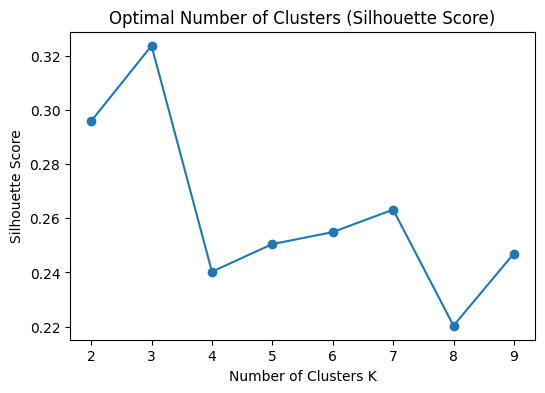

Best K based on silhouette score: 3


In [20]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Sample for silhouette calculation
# -----------------------------
sample_size = min(5000, X_scaled.shape[0])  # max 5000 or dataset size
X_sample = resample(X_scaled, n_samples=sample_size, random_state=42)

# -----------------------------
# Step 2: Find optimal K
# -----------------------------
silhouette_scores = []

for k in range(2, 10):
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000)
    kmeans.fit(X_scaled)  # fit on full data for cluster centers
    # silhouette on the sample for speed
    labels_sample = kmeans.predict(X_sample)
    score = silhouette_score(X_sample, labels_sample)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(6,4))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.title('Optimal Number of Clusters (Silhouette Score)')
plt.xlabel('Number of Clusters K')
plt.ylabel('Silhouette Score')
plt.show()

# Choose best K
best_k = range(2, 10)[silhouette_scores.index(max(silhouette_scores))]
print(f"Best K based on silhouette score: {best_k}")

# -----------------------------
# Step 3: Fit final model on full dataset
# -----------------------------
final_kmeans = MiniBatchKMeans(n_clusters=best_k, random_state=42, batch_size=1000)
rfm['kmeans_cluster'] = final_kmeans.fit_predict(X_scaled)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=rfm['kmeans_cluster'], cmap='viridis', s=40, alpha=0.7)
plt.title('Customer Segmentation via K-Means (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [ ]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=50)
rfm['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Hierarchical
agg = AgglomerativeClustering(n_clusters=4)
rfm['agg_cluster'] = agg.fit_predict(X_scaled)


In [ ]:
def evaluate_clusters(X, labels, name):
    print(f"\n{name} Clustering Metrics:")
    print("Silhouette:", silhouette_score(X, labels))
    print("Davies-Bouldin:", davies_bouldin_score(X, labels))
    print("Calinski-Harabasz:", calinski_harabasz_score(X, labels))

evaluate_clusters(X_scaled, rfm['kmeans_cluster'], 'K-Means')
evaluate_clusters(X_scaled, rfm['agg_cluster'], 'Hierarchical')


In [ ]:
summary = rfm.groupby('kmeans_cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'avg_review': 'mean',
    'avg_installments': 'mean',
    'avg_delivery_time': 'mean',
    'category_diversity': 'mean'
}).round(2)

print(summary)


In [ ]:
cluster_labels = {
    0: 'Loyal High Spenders',
    1: 'At-Risk Shoppers',
    2: 'New or Occasional Buyers',
    3: 'Low-Engagement Customers'
}

rfm['customer_segment'] = rfm['kmeans_cluster'].map(cluster_labels)
rfm[['kmeans_cluster', 'customer_segment']].head()


In [ ]:
sns.set(style="whitegrid", palette="Set2")

plt.figure(figsize=(14, 8))
for i, feature in enumerate(['recency','frequency','monetary','avg_review']):
    plt.subplot(2,2,i+1)
    sns.boxplot(data=rfm, x='customer_segment', y=feature)
    plt.title(f'{feature} by Customer Segment')
    plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
